# GABLS1 LES Intercomparison Study for Stable Boundary Layers: Fourier Spectra

In [1]:
from IPython.display import display, Markdown
from datetime import datetime, timezone
display(Markdown(f"*Last run: {datetime.now(timezone.utc).strftime('%B %d, %Y at %H:%M UTC')}*"))

*Last run: June 24, 2026 at 09:27 UTC*

For case setup and physical parameters, see the [Description](SBL_GABLS1_Description.ipynb) notebook.

One-sided Fourier power spectra of the streamwise velocity $u$ and potential temperature $\theta$ are computed at four height levels. The 1-D spectrum is computed along $x$ for each $y$ row and then averaged over $y$. Reference run: `256x256x256_LASDD_SM_DP` at $t = 9$ h.

## Setup

In [52]:
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

### Output directory

In [53]:
def find_repo_root(start=None):
    path = Path(start or ('__file__' in globals() and __file__) or Path.cwd()).resolve()
    for candidate in (path, *path.parents):
        if (candidate / 'examples').is_dir() and (candidate / 'docs').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate jaxalfa repository root')

BaseDir = find_repo_root()

RunDir    = BaseDir / 'examples/SBL_GABLS1/runs/256x256x256_LASDD_SM_DP'
OutputDir = RunDir / 'output'

cfg = {}
exec((RunDir / 'Config.py').read_text(), cfg)

### Load 3D fields at $t = 9$ h

In [54]:
T_snapshot = 9 * 3600
dt = float(cfg['dt'])
iter_3D = int(T_snapshot / dt)
field_path = OutputDir / f'ALFA_3DFields_Iteration_{iter_3D}.npz'

nx = int(cfg['nx']); ny = int(cfg['ny']); nz = int(cfg['nz'])

if field_path.exists():
    File3D = np.load(field_path)
    u3D  = File3D['u']
    TH3D = File3D['TH']
    print(f'Loaded {field_path.name}  shape: {u3D.shape}')
else:
    print(f'Missing {field_path}; using NaN placeholders.')
    u3D  = np.full((nx, ny, nz), np.nan)
    TH3D = np.full((nx, ny, nz), np.nan)

Loaded ALFA_3DFields_Iteration_648000.npz  shape: (256, 256, 256)


### Grid parameters

In [55]:
l_x = float(cfg['l_x'])
l_z = float(cfg['l_z'])
dx  = l_x / nx

# Half levels — u and TH
z_u = np.array([(k + 0.5) * l_z / (nz - 1) for k in range(nz)])

# Height levels matching HorizontalCrossSections notebook
k_levels = [int(nz / 32), int(nz / 16), int(nz / 8), int(nz / 4)]
z_labels  = [f'{z_u[k]:.1f}' for k in k_levels]

print('Height levels (k, z):')
for k, zl in zip(k_levels, z_labels):
    print(f'  k={k:4d}  z={zl} m')
print(f'dx = {dx:.4f} m')

Height levels (k, z):
  k=   8  z=13.3 m
  k=  16  z=25.9 m
  k=  32  z=51.0 m
  k=  64  z=101.2 m
dx = 1.5625 m


### Fourier spectrum

In [56]:
def FourSpectrum1D_LES(X, dx):
    """Compute 1-D one-sided power spectral density averaged over axis 1.

    Translated from LES_FourSpectrum.m (Sukanta Basu, 2005).

    Parameters
    ----------
    X : ndarray (NI, NJ)
        Field slice; axis 0 is the x-direction, axis 1 is averaged over (y).
    dx : float
        Grid spacing in the x-direction (m); sets the wavenumber bin width.

    Returns
    -------
    P : ndarray (NI//2 - 1,)  — PSD averaged over y; DC and Nyquist excluded.
        Units: [X]^2 / (rad m^-1)  (e.g. m^3 s^-2 rad^-1 for velocity).
    """
    NI, NJ = X.shape
    N = NI
    P = np.zeros(N)
    for j in range(NJ):
        f = np.fft.fft(X[:, j]) / N
        P += 2.0 * np.abs(f) ** 2
    P /= NJ
    dK = 2.0 * np.pi / (N * dx)   # wavenumber bin width (rad/m)
    return P[1 : N // 2] / dK     # convert to PSD per unit wavenumber

In [57]:
plt.rcParams.update({
    'text.usetex': True,
    'font.size': 14,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})

## Fourier Spectra of $u$

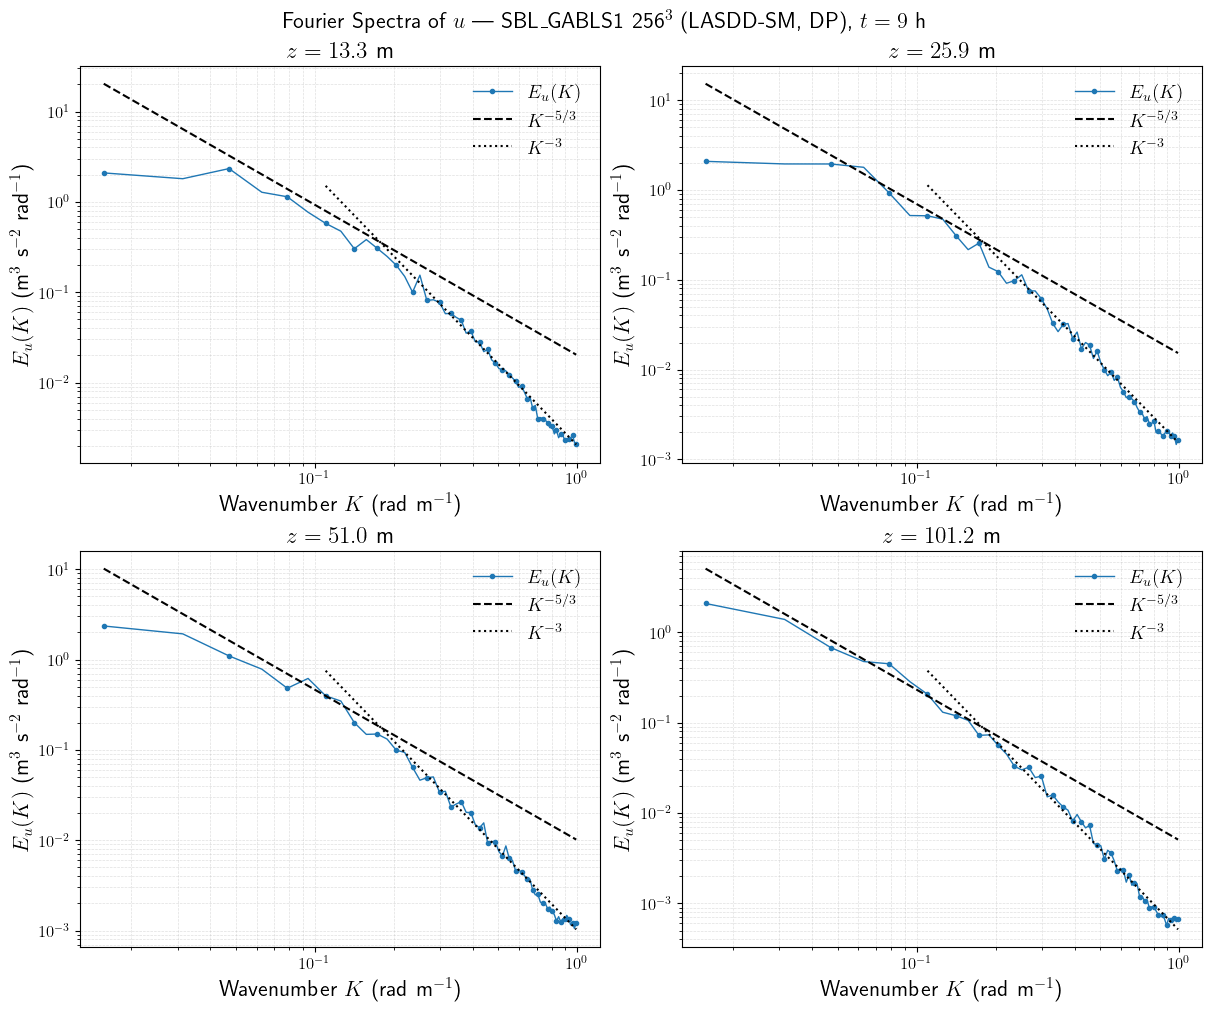

In [65]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
axs = axs.flatten()

FGR  = float(cfg['FGR'])
N        = nx
K        = 2.0 * np.pi * np.arange(1, N // 2) / (N * dx)   # rad/m
K_c      = np.pi / (FGR * dx)                                # filter cutoff (rad/m)
mask_c = K < K_c
mask_hi = K[mask_c] >= 0.1 * K_c               # high-K region for K^{-3} reference

A_ref_u  = [2e-2, 1.5e-2, 1e-2, 5e-3]   # one pre-factor per height level; adjust to shift K^{-5/3}
A_ref_u3 = [2e-3, 1.5e-3, 1e-3, 5e-4]   # adjust to shift K^{-3}

for i, k in enumerate(k_levels):
    P      = FourSpectrum1D_LES(u3D[:, :, k], dx)
    K_plt  = K[mask_c]
    P_plt  = P[mask_c]

    ax = axs[i]
    ax.loglog(K_plt, P_plt, color='tab:blue', marker='o',
              markevery=2, markersize=3, linewidth=1.0, label=r'$E_u(K)$')
    ax.loglog(K_plt,        A_ref_u[i]  * K_plt        ** (-5 / 3), 'k--', linewidth=1.5, label=r'$K^{-5/3}$')
    ax.loglog(K_plt[mask_hi], A_ref_u3[i] * K_plt[mask_hi] ** (-3), 'k:', linewidth=1.5, label=r'$K^{-3}$')

    ax.set_title(rf'$z = {z_labels[i]}$ m')
    ax.set_xlabel(r'Wavenumber $K$ (rad m$^{-1}$)')
    ax.set_ylabel(r'$E_u(K)$ (m$^3$ s$^{-2}$ rad$^{-1}$)')
    ax.legend(frameon=False)
    ax.grid(True, which='both', ls='--', alpha=0.4)

fig.suptitle(r'Fourier Spectra of $u$ — SBL\_GABLS1 256$^3$ (LASDD-SM, DP), $t=9$ h', fontsize=16)
plt.show()

## Fourier Spectra of $\theta$

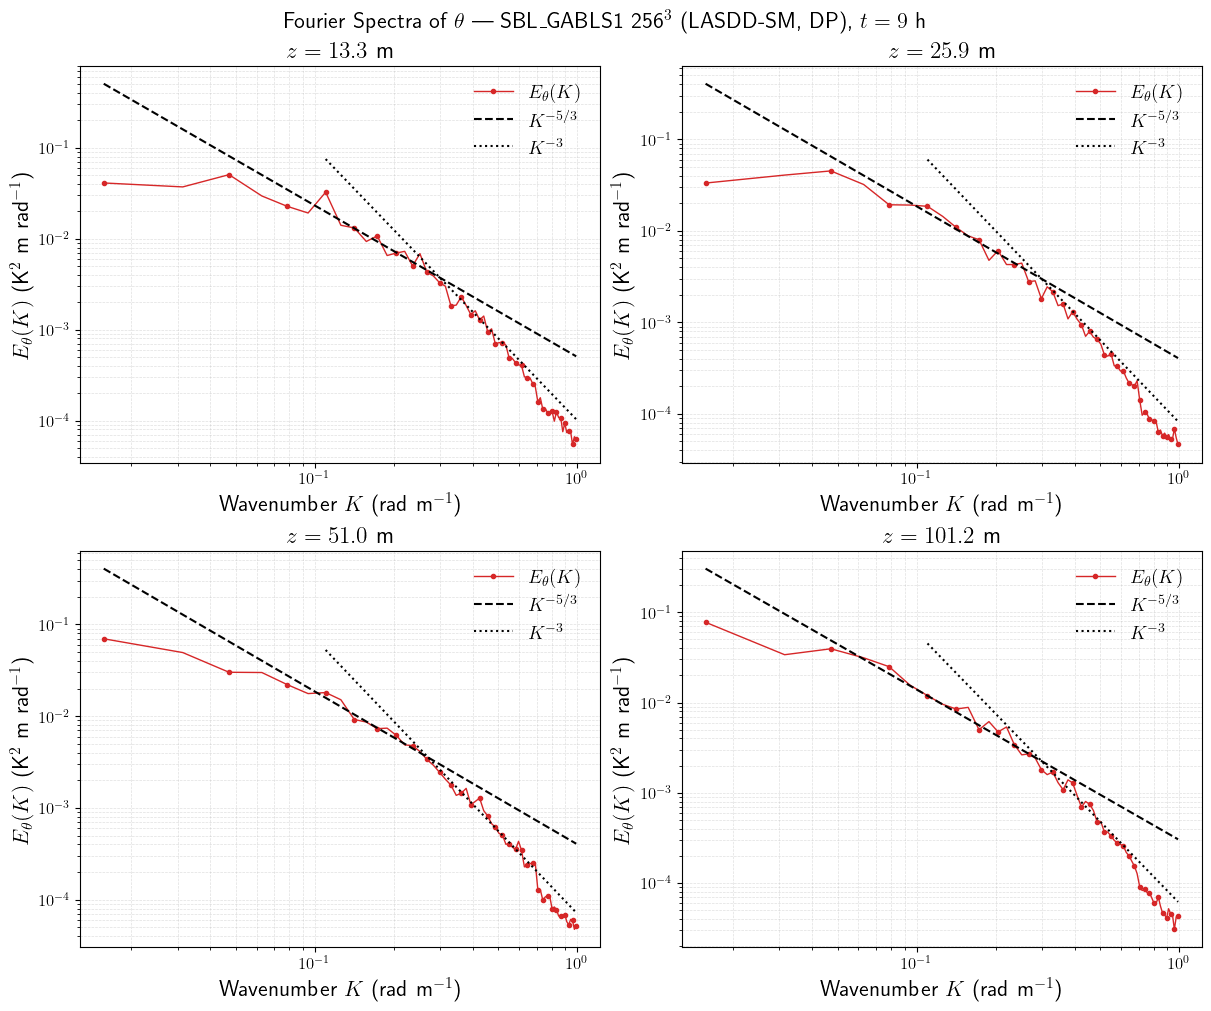

In [70]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
axs = axs.flatten()

A_ref_th  = [5e-4, 4e-4, 4e-4, 3e-4]   # one pre-factor per height level; adjust to shift K^{-5/3}
A_ref_th3 = [1e-4, 8e-5, 7e-5, 6e-5]   # adjust to shift K^{-3}

for i, k in enumerate(k_levels):
    P      = FourSpectrum1D_LES(TH3D[:, :, k], dx)
    K_plt  = K[mask_c]
    P_plt  = P[mask_c]

    ax = axs[i]
    ax.loglog(K_plt, P_plt, color='tab:red', marker='o',
              markevery=2, markersize=3, linewidth=1.0, label=r'$E_\theta(K)$')
    ax.loglog(K_plt,        A_ref_th[i]  * K_plt        ** (-5 / 3), 'k--', linewidth=1.5, label=r'$K^{-5/3}$')
    ax.loglog(K_plt[mask_hi], A_ref_th3[i] * K_plt[mask_hi] ** (-3), 'k:', linewidth=1.5, label=r'$K^{-3}$')

    ax.set_title(rf'$z = {z_labels[i]}$ m')
    ax.set_xlabel(r'Wavenumber $K$ (rad m$^{-1}$)')
    ax.set_ylabel(r'$E_\theta(K)$ (K$^2$ m rad$^{-1}$)')
    ax.legend(frameon=False)
    ax.grid(True, which='both', ls='--', alpha=0.4)

fig.suptitle(r'Fourier Spectra of $\theta$ — SBL\_GABLS1 256$^3$ (LASDD-SM, DP), $t=9$ h',
             fontsize=16)
plt.show()